In [1]:
import pandas as pd
import yfinance as yf

In [2]:
import os

os.makedirs("../outputs/charts", exist_ok=True)

def save_chart(name):
    plt.savefig(
        f"../outputs/charts/{name}.png",
        dpi=300,
        bbox_inches="tight"
    )

In [3]:
apple= yf.download("AAPL", period="5y")

[*********************100%***********************]  1 of 1 completed


In [4]:
apple

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-07-26,145.228287,146.047075,143.970848,144.526464,72434100
2021-07-27,143.064331,145.442728,141.875133,145.354989,104818600
2021-07-28,141.319519,143.259281,138.941122,141.153813,118931200
2021-07-29,141.962875,142.849903,140.929641,141.036864,56699500
2021-07-30,142.177338,142.635472,140.471522,140.734709,70440600
...,...,...,...,...,...
2026-07-20,326.589996,333.709991,323.679993,333.510010,53468000
2026-07-21,327.739990,329.600006,322.220001,323.130005,41338900


In [5]:
apple.shape

(1255, 5)

In [6]:
apple.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [7]:
apple.index

DatetimeIndex(['2021-07-26', '2021-07-27', '2021-07-28', '2021-07-29',
               '2021-07-30', '2021-08-02', '2021-08-03', '2021-08-04',
               '2021-08-05', '2021-08-06',
               ...
               '2026-07-13', '2026-07-14', '2026-07-15', '2026-07-16',
               '2026-07-17', '2026-07-20', '2026-07-21', '2026-07-22',
               '2026-07-23', '2026-07-24'],
              dtype='datetime64[s]', name='Date', length=1255, freq=None)

In [8]:
apple.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1255 entries, 2021-07-26 to 2026-07-24
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1255 non-null   float64
 1   (High, AAPL)    1255 non-null   float64
 2   (Low, AAPL)     1255 non-null   float64
 3   (Open, AAPL)    1255 non-null   float64
 4   (Volume, AAPL)  1255 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


In [9]:
apple.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,196.093959,198.049944,193.950636,195.881251,6.472425e+07
std,46.661978,47.037813,46.221757,46.585501,2.856452e+07
min,122.933540,125.637646,122.097738,123.907048,1.791060e+07
25%,158.344742,160.390312,156.245985,158.068453,4.551590e+07
50%,184.680222,186.004540,182.431925,184.452136,5.669700e+07
75%,228.394341,230.303412,225.966094,227.997848,7.643635e+07
max,333.739990,334.989990,329.000000,333.510010,3.186799e+08


In [10]:
apple.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

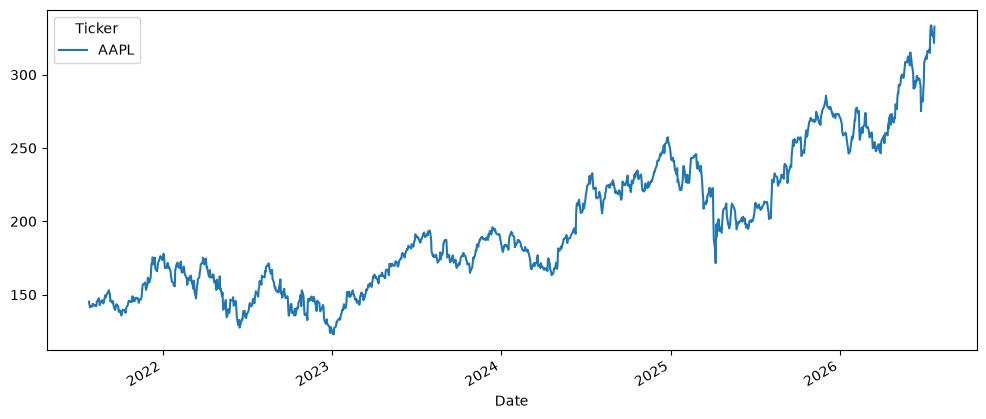

In [88]:
apple["Close"].plot(figsize=(12,5))
save_chart("close_price")

In [12]:
type(apple["Close"])

pandas.DataFrame

In [13]:
print(type(apple["Close"]))

<class 'pandas.DataFrame'>


In [14]:
print(type(apple["Close"]["AAPL"]))

<class 'pandas.Series'>


<Axes: xlabel='Date'>

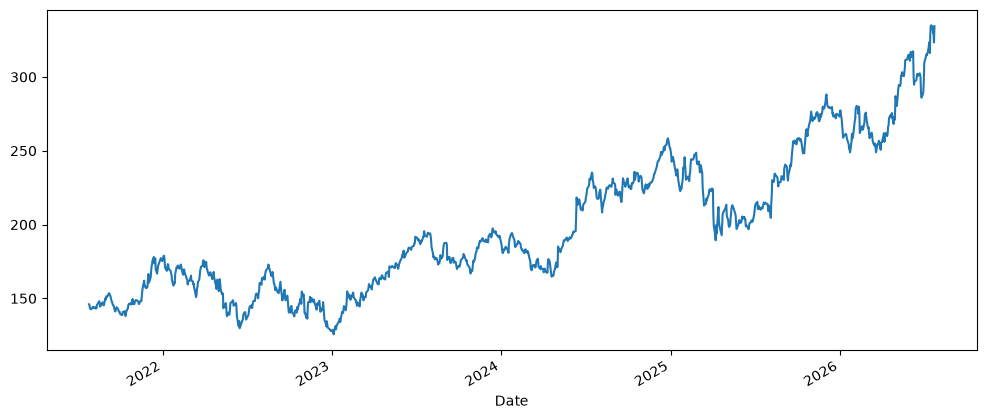

In [15]:
apple["High"]["AAPL"].plot(figsize=(12,5))

In [16]:
close = apple["Close"]["AAPL"]
high = apple["High"]["AAPL"]
close.corr(high)

np.float64(0.9991704255765073)

In [17]:
import matplotlib.pyplot as plt

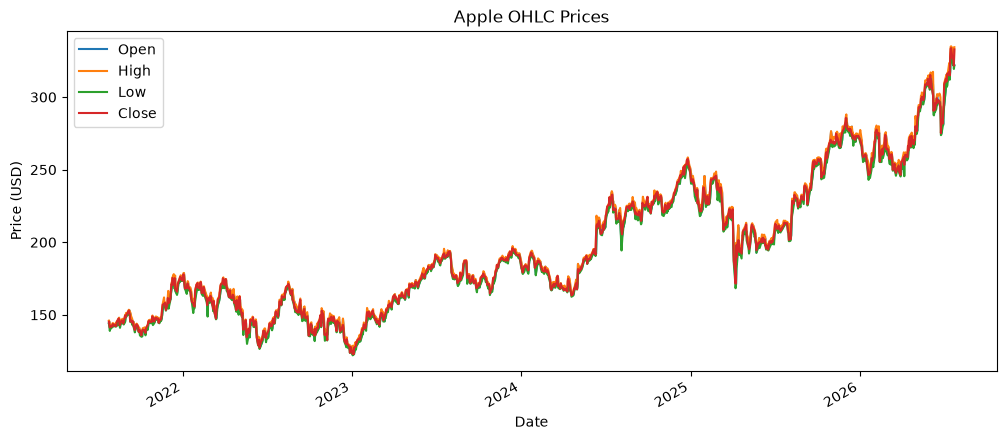

In [82]:
plt.figure(figsize=(12,5))
apple["Open"]["AAPL"].plot(label="Open")
apple["High"]["AAPL"].plot(label="High")
apple["Low"]["AAPL"].plot(label="Low")
apple["Close"]["AAPL"].plot(label="Close")

plt.legend()
plt.title("Apple OHLC Prices")
plt.ylabel("Price (USD)")
save_chart("apple_ohlc")
plt.show()

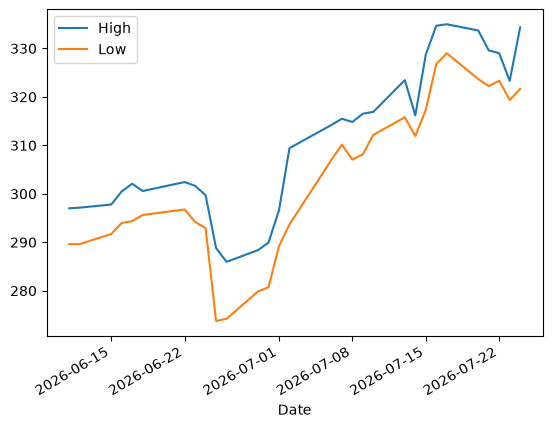

In [81]:
apple_last_month = apple.tail(30)
apple_last_month["High"]["AAPL"].plot(label="High")
apple_last_month["Low"]["AAPL"].plot(label="Low")
save_chart("high_vs_low_last_month")

plt.legend()
plt.show()

In [20]:
apple["Daily Return"]= apple["Close"]["AAPL"].pct_change()

In [21]:
apple.head()

Price,Close,High,Low,Open,Volume,Daily Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2021-07-26,145.228287,146.047075,143.970848,144.526464,72434100,NaN
2021-07-27,143.064331,145.442728,141.875133,145.354989,104818600,-0.014900
2021-07-28,141.319519,143.259281,138.941122,141.153813,118931200,-0.012196
2021-07-29,141.962875,142.849903,140.929641,141.036864,56699500,0.004552
2021-07-30,142.177338,142.635472,140.471522,140.734709,70440600,0.001511


In [22]:
apple.tail()

Price,Close,High,Low,Open,Volume,Daily Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2026-07-20,326.589996,333.709991,323.679993,333.510010,53468000,-0.021424
2026-07-21,327.739990,329.600006,322.220001,323.130005,41338900,0.003521
2026-07-22,325.890015,329.000000,323.339996,327.869995,38755900,-0.005645
2026-07-23,321.660004,323.299988,319.350006,321.730011,40812200,-0.012980
2026-07-24,332.820007,334.369995,321.619995,322.040009,33661749,0.034695


In [23]:
apple[["Close","Daily Return"]].head(10)

Price,Close,Daily Return
Ticker,AAPL,
Date,,
2021-07-26,145.228287,NaN
2021-07-27,143.064331,-0.014900
2021-07-28,141.319519,-0.012196
2021-07-29,141.962875,0.004552
2021-07-30,142.177338,0.001511
2021-08-02,141.845886,-0.002331
2021-08-03,143.639465,0.012645
2021-08-04,143.239792,-0.002782


In [24]:
apple["Daily Return"].mean()

np.float64(0.0008143585274284869)

In [25]:
apple["Daily Return"].max()

np.float64(0.15328843665210412)

In [26]:
apple["Daily Return"].min()

np.float64(-0.09245611817424748)

In [27]:
apple["Daily Return"].idxmax()

Timestamp('2025-04-09 00:00:00')

In [28]:
apple["Daily Return"].idxmin()

Timestamp('2025-04-03 00:00:00')

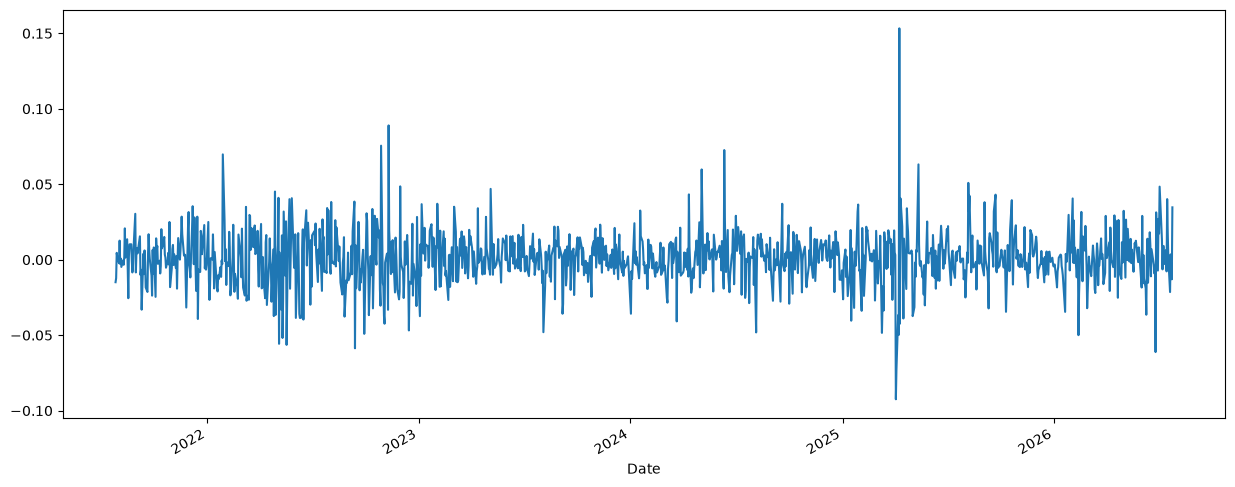

In [83]:
apple["Daily Return"].plot(figsize=(15,6))
save_chart("daily_return")

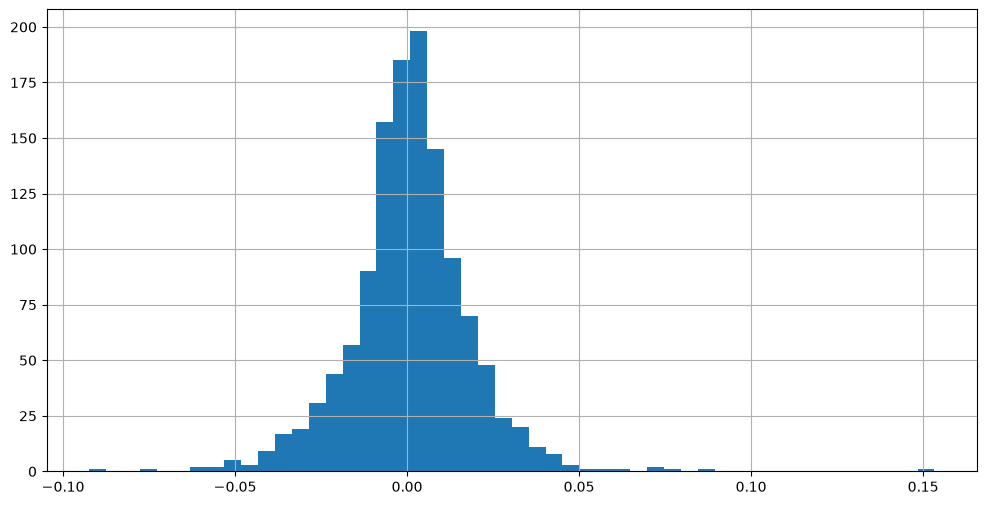

In [30]:
apple["Daily Return"].hist(figsize=(12,6),bins=50)
save_chart("daily_return_histogram")

In [31]:
apple["Daily Return"].std()

np.float64(0.017529859659190482)

In [32]:
apple["MA20"]=apple["Close"]["AAPL"].rolling(window=20).mean()

In [33]:
apple[["Close","MA20"]].tail(10)

Price,Close,MA20
Ticker,AAPL,
Date,,
2026-07-13,317.309998,299.187001
2026-07-14,314.859985,300.373500
2026-07-15,327.500000,301.927499
2026-07-16,333.260010,303.628500
2026-07-17,333.739990,305.517999
2026-07-20,326.589996,306.946999
2026-07-21,327.739990,308.483498
2026-07-22,325.890015,310.062999


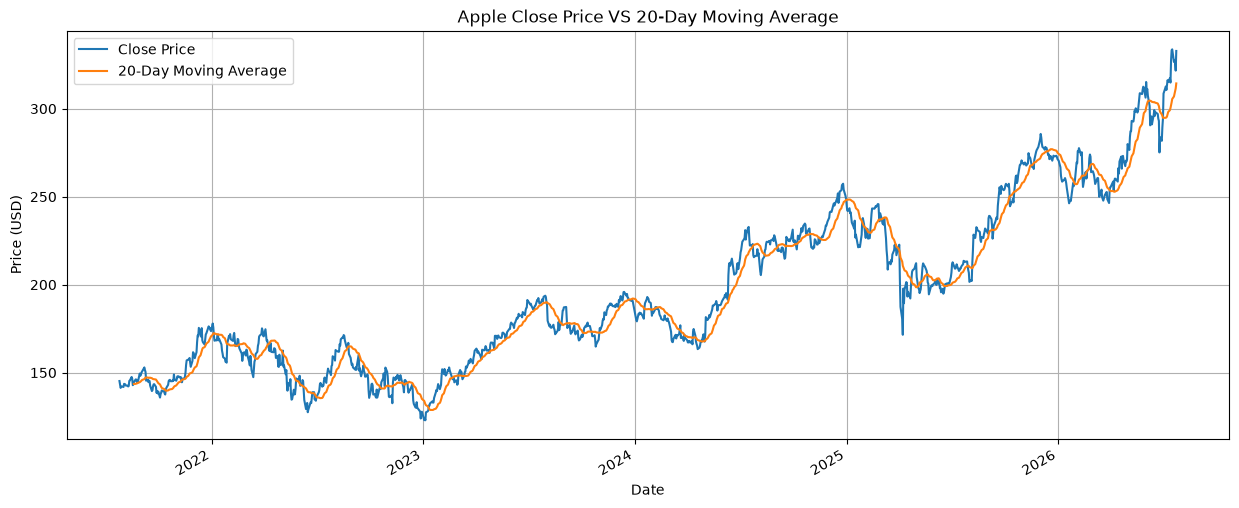

In [84]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,6))
apple["Close"]["AAPL"].plot(label="Close Price")
apple["MA20"].plot(label="20-Day Moving Average")
plt.title("Apple Close Price VS 20-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
save_chart("ma20")
plt.show()



In [35]:
apple["MA50"]=apple["Close"]["AAPL"].rolling(window=50).mean()

In [36]:
apple[["Close","MA20","MA50"]].tail(10)

Price,Close,MA20,MA50
Ticker,AAPL,,
Date,,,
2026-07-13,317.309998,299.187001,298.674736
2026-07-14,314.859985,300.373500,299.549930
2026-07-15,327.500000,301.927499,300.502288
2026-07-16,333.260010,303.628500,301.635984
2026-07-17,333.739990,305.517999,302.632416
2026-07-20,326.589996,306.946999,303.419308
2026-07-21,327.739990,308.483498,304.230600
2026-07-22,325.890015,310.062999,304.887400


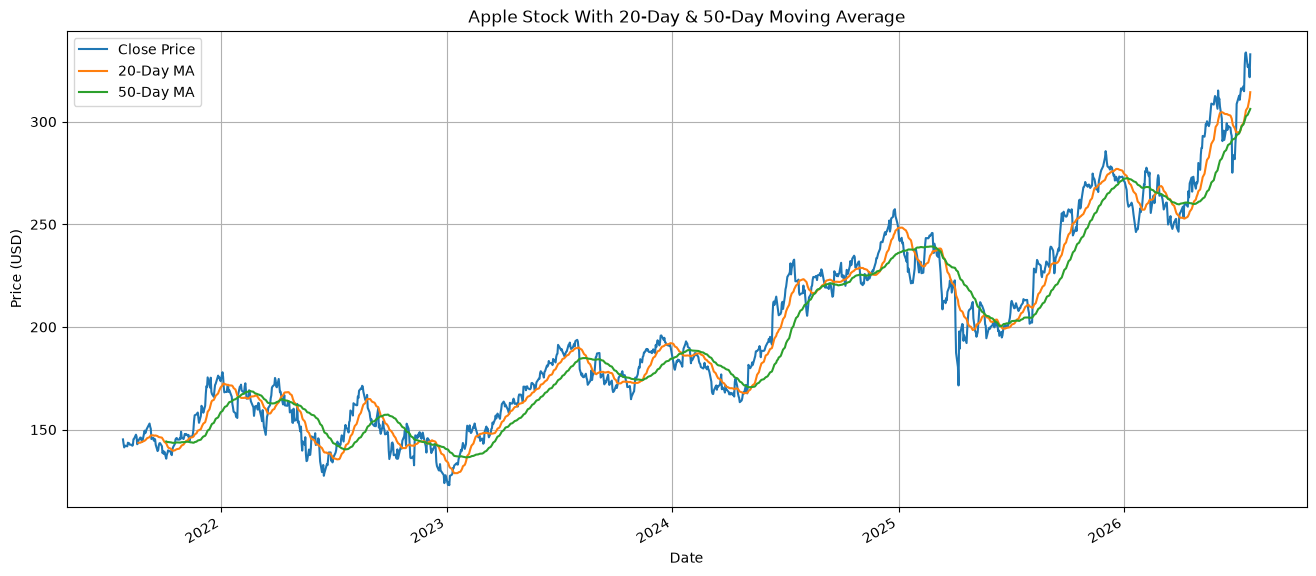

In [37]:
plt.figure(figsize=(16,7))
apple["Close"]["AAPL"].plot(label="Close Price")
apple["MA20"].plot(label="20-Day MA")
apple["MA50"].plot(label="50-Day MA")
plt.title("Apple Stock With 20-Day & 50-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
save_chart("ma20_ma50")
plt.show()

In [38]:
apple["Signal"]=0

In [39]:
apple.loc[apple["MA20"]>apple["MA50"],"Signal"]=1

In [40]:
apple[["Close","MA20","MA50","Signal"]].tail(20)

Price,Close,MA20,MA50,Signal
Ticker,AAPL,,,
Date,,,,
2026-06-26,283.779999,298.288501,291.411648,1
2026-06-29,281.739990,296.772501,291.783297,1
2026-06-30,289.359985,295.925000,292.170872,1
2026-07-01,294.380005,294.884000,292.602499,1
2026-07-02,308.630005,294.802499,293.456599,1
2026-07-06,312.660004,294.873999,294.251427,1
2026-07-07,310.660004,295.039999,295.001061,1
2026-07-08,313.390015,295.632500,295.852651,0


In [41]:
apple["Position"]=apple["Signal"].diff()

In [42]:
apple[apple["Position"]==1]

Price,Close,High,Low,Open,Volume,Daily Return,MA20,MA50,Signal,Position
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Date,,,,,,,,,,
2021-11-04,147.369034,148.804052,147.056639,147.974281,60394600,-0.003498,143.995227,143.967695,1,1.0
2022-04-05,171.363190,174.534775,170.736705,173.751666,73401800,-0.018942,164.161069,164.037352,1,1.0
2022-07-20,150.028320,150.694946,147.410865,148.146106,64823400,0.013510,140.828004,140.344113,1,1.0
2022-11-21,145.539886,147.860502,145.254733,147.654015,58724100,-0.021680,144.228578,144.143313,1,1.0
2022-12-01,145.834869,146.641192,144.163243,145.736547,71250400,0.001892,143.323003,143.269233,1,1.0
2023-02-03,151.921555,154.753495,145.362872,145.559531,154357300,0.024400,137.165996,136.572472,1,1.0
2023-11-14,185.342041,186.004540,184.214801,185.599125,60108400,0.014286,174.384034,174.147057,1,1.0
2024-05-08,180.925232,181.251957,179.648034,181.034140,45057100,0.001864,170.838392,170.687111,1,1.0


In [43]:
apple.columns

MultiIndex([(       'Close', 'AAPL'),
            (        'High', 'AAPL'),
            (         'Low', 'AAPL'),
            (        'Open', 'AAPL'),
            (      'Volume', 'AAPL'),
            ('Daily Return',     ''),
            (        'MA20',     ''),
            (        'MA50',     ''),
            (      'Signal',     ''),
            (    'Position',     '')],
           names=['Price', 'Ticker'])

In [44]:
buy = apple[apple["Position"]==1]
buy

Price,Close,High,Low,Open,Volume,Daily Return,MA20,MA50,Signal,Position
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Date,,,,,,,,,,
2021-11-04,147.369034,148.804052,147.056639,147.974281,60394600,-0.003498,143.995227,143.967695,1,1.0
2022-04-05,171.363190,174.534775,170.736705,173.751666,73401800,-0.018942,164.161069,164.037352,1,1.0
2022-07-20,150.028320,150.694946,147.410865,148.146106,64823400,0.013510,140.828004,140.344113,1,1.0
2022-11-21,145.539886,147.860502,145.254733,147.654015,58724100,-0.021680,144.228578,144.143313,1,1.0
2022-12-01,145.834869,146.641192,144.163243,145.736547,71250400,0.001892,143.323003,143.269233,1,1.0
2023-02-03,151.921555,154.753495,145.362872,145.559531,154357300,0.024400,137.165996,136.572472,1,1.0
2023-11-14,185.342041,186.004540,184.214801,185.599125,60108400,0.014286,174.384034,174.147057,1,1.0
2024-05-08,180.925232,181.251957,179.648034,181.034140,45057100,0.001864,170.838392,170.687111,1,1.0


In [45]:
sell = apple[apple["Position"]==-1]
sell

Price,Close,High,Low,Open,Volume,Daily Return,MA20,MA50,Signal,Position
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Date,,,,,,,,,,
2022-01-31,170.871399,171.086480,165.719248,166.354721,115541600,0.026126,166.062893,166.208663,0,-1.0
2022-05-03,156.112198,157.316234,153.018940,154.810282,88966500,0.009623,161.569972,161.967884,0,-1.0
2022-09-19,151.650330,151.728866,146.368887,146.575032,81474200,0.025083,156.073299,156.620109,0,-1.0
2022-11-29,138.814026,142.393278,138.007719,141.881952,83763800,-0.021149,143.266478,143.539951,0,-1.0
2022-12-19,130.160889,132.943661,129.128424,132.855167,79592600,-0.015909,141.535345,142.204685,0,-1.0
2023-08-16,174.363983,176.309357,174.294850,174.916984,46964900,-0.004959,184.406290,184.729250,0,-1.0
2024-01-17,180.635315,180.882517,178.281964,179.241108,47317400,-0.005173,186.683855,187.173354,0,-1.0
2024-08-20,224.824646,225.479739,223.772535,224.090162,30299000,0.002745,216.757353,217.003023,0,-1.0


In [46]:
type(buy)
type(sell)

pandas.DataFrame

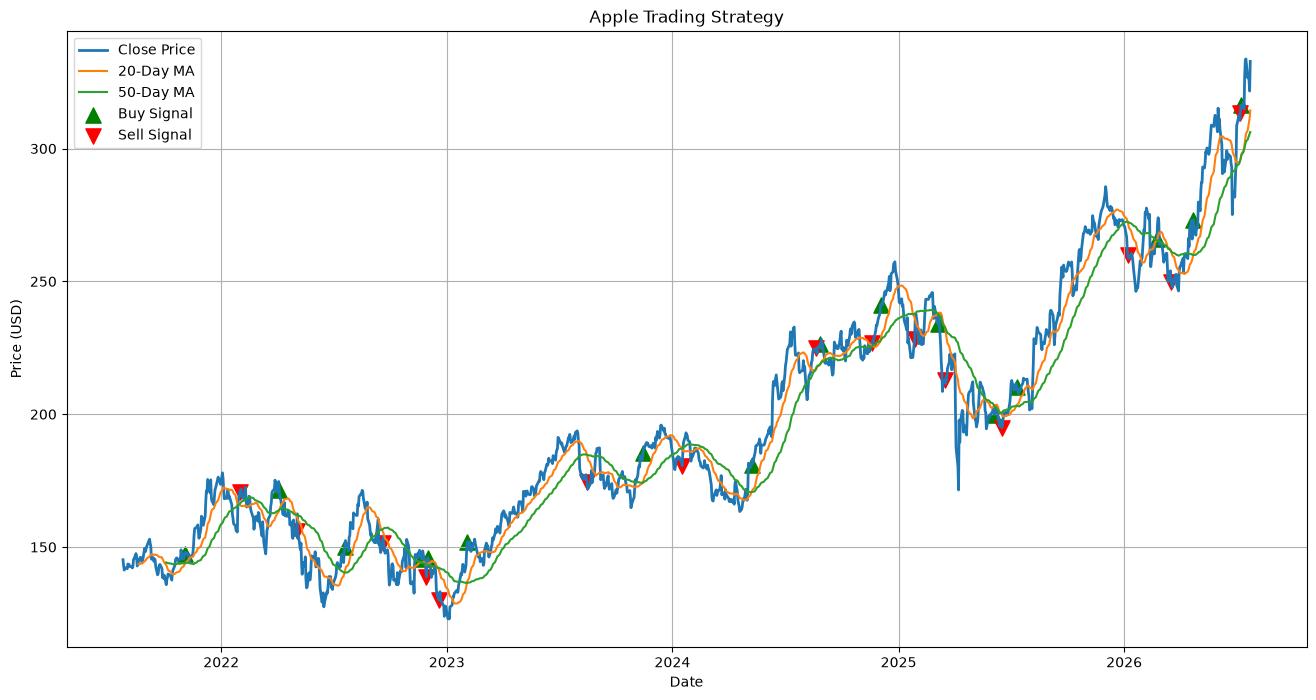

In [85]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16,8))

#Close Price
plt.plot(apple.index, apple["Close"]["AAPL"],label="Close Price",linewidth=2)

#MA20
plt.plot(apple.index, apple["MA20"],label="20-Day MA")

#MA50
plt.plot(apple.index, apple["MA50"],label="50-Day MA")

#BUY Signal
plt.scatter(buy.index, buy["Close"]["AAPL"], marker="^",color="green",s=120,label="Buy Signal")

#SELL Signal
plt.scatter(sell.index, sell["Close"]["AAPL"], marker="v",color="red",s=120,label="Sell Signal")

plt.title("Apple Trading Strategy")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
save_chart("trading_strategy")
plt.show()


In [48]:
apple["Trade"]=apple["Signal"].diff()
apple[["Signal","Trade"]].tail(20)

Price,Signal,Trade
Ticker,,
Date,,
2026-06-26,1,0.0
2026-06-29,1,0.0
2026-06-30,1,0.0
2026-07-01,1,0.0
2026-07-02,1,0.0
2026-07-06,1,0.0
2026-07-07,1,0.0
2026-07-08,0,-1.0


In [49]:
apple[apple["Trade"] != 0][["Close","Trade"]]

Price,Close,Trade
Ticker,AAPL,
Date,,
2021-07-26,145.228287,NaN
2021-11-04,147.369034,1.0
2022-01-31,170.871399,-1.0
2022-04-05,171.363190,1.0
2022-05-03,156.112198,-1.0
2022-07-20,150.028320,1.0
2022-09-19,151.650330,-1.0
2022-11-21,145.539886,1.0


In [50]:
apple["Trade"].value_counts()

Trade
 0.0    1223
 1.0      16
-1.0      15
Name: count, dtype: int64

In [51]:
apple["Trade"].abs().sum()

np.float64(31.0)

In [52]:
apple["Market Return"] = apple["Close"].pct_change()

In [53]:
apple[["Close","Market Return"]].head(10)

Price,Close,Market Return
Ticker,AAPL,
Date,,
2021-07-26,145.228287,NaN
2021-07-27,143.064331,-0.014900
2021-07-28,141.319519,-0.012196
2021-07-29,141.962875,0.004552
2021-07-30,142.177338,0.001511
2021-08-02,141.845886,-0.002331
2021-08-03,143.639465,0.012645
2021-08-04,143.239792,-0.002782


In [54]:
apple["Strategy Return"]=apple["Signal"].shift(1)*apple["Market Return"]

In [55]:
apple[["Close","Market Return","Strategy Return"]].head(10)

Price,Close,Market Return,Strategy Return
Ticker,AAPL,,
Date,,,
2021-07-26,145.228287,NaN,NaN
2021-07-27,143.064331,-0.014900,-0.0
2021-07-28,141.319519,-0.012196,-0.0
2021-07-29,141.962875,0.004552,0.0
2021-07-30,142.177338,0.001511,0.0
2021-08-02,141.845886,-0.002331,-0.0
2021-08-03,143.639465,0.012645,0.0
2021-08-04,143.239792,-0.002782,-0.0


In [56]:
apple[["Close","Market Return","Strategy Return"]].tail(10)

Price,Close,Market Return,Strategy Return
Ticker,AAPL,,
Date,,,
2026-07-13,317.309998,0.006311,0.006311
2026-07-14,314.859985,-0.007721,-0.007721
2026-07-15,327.500000,0.040145,0.040145
2026-07-16,333.260010,0.017588,0.017588
2026-07-17,333.739990,0.001440,0.001440
2026-07-20,326.589996,-0.021424,-0.021424
2026-07-21,327.739990,0.003521,0.003521
2026-07-22,325.890015,-0.005645,-0.005645


In [57]:
apple["Portfolio"]=(1 + apple["Strategy Return"]).cumprod()*100000

In [58]:
apple[["Strategy Return","Portfolio"]].tail(10)

Price,Strategy Return,Portfolio
Ticker,,
Date,,
2026-07-13,0.006311,142032.717330
2026-07-14,-0.007721,140936.055095
2026-07-15,0.040145,146593.915362
2026-07-16,0.017588,149172.182184
2026-07-17,0.001440,149387.028645
2026-07-20,-0.021424,146186.584065
2026-07-21,0.003521,146701.338593
2026-07-22,-0.005645,145873.261755


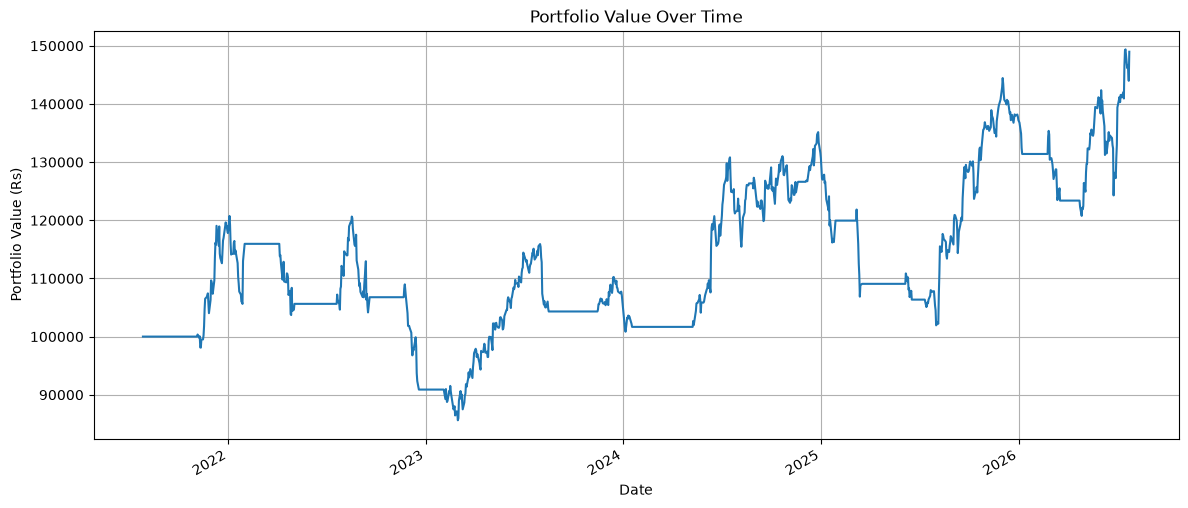

In [86]:
plt.figure(figsize=(14,6))
apple["Portfolio"].plot()
plt.title("Portfolio Value Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Rs)")
plt.grid(True)
save_chart("portfolio")
plt.show()

In [60]:
apple["Buy Hold"]=(1 + apple["Market Return"]).cumprod()*100000

In [61]:
apple[["Portfolio","Buy Hold"]].tail()

Price,Portfolio,Buy Hold
Ticker,,
Date,,
2026-07-20,146186.584065,224880.430433
2026-07-21,146701.338593,225672.282986
2026-07-22,145873.261755,224398.443276
2026-07-23,143979.845350,221485.779992
2026-07-24,148975.230487,229170.235901


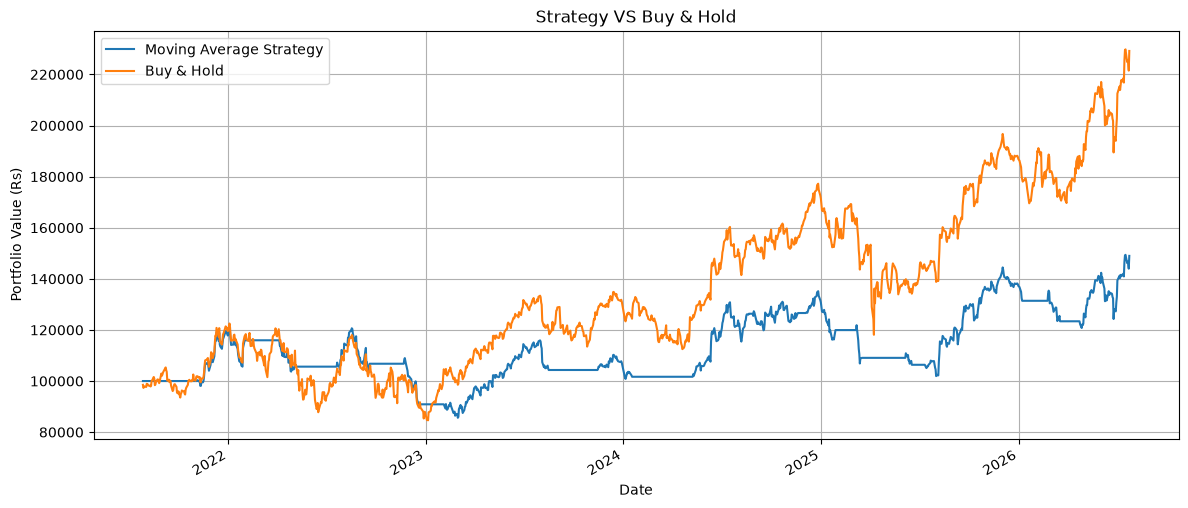

In [87]:
plt.figure(figsize=(14,6))
apple["Portfolio"].plot(label="Moving Average Strategy")
apple["Buy Hold"].plot(label="Buy & Hold")
plt.title("Strategy VS Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Rs)")
plt.legend()
plt.grid(True)
save_chart("strategy_vs_buy_hold")
plt.show()

In [63]:
strategy_return = ((apple["Portfolio"].iloc[-1] - 100000) / 100000)*100
print("Strategy Return (%):", round(strategy_return,2))

Strategy Return (%): 48.98


In [64]:
buyhold_return = ((apple["Buy Hold"].iloc[-1] - 100000) / 100000)*100
print("Buy & Hold Return (%):", round(buyhold_return,2))

Buy & Hold Return (%): 129.17


In [65]:
apple["Trade"].value_counts()

Trade
 0.0    1223
 1.0      16
-1.0      15
Name: count, dtype: int64

In [66]:
buy_signals = (apple["Trade"] == 1).sum()
sell_signals = (apple["Trade"] == -1).sum()
print("Buy Signals:", buy_signals)
print("Sell Signals:", sell_signals)

Buy Signals: 16
Sell Signals: 15


In [67]:
apple["Peak"] = apple["Portfolio"].cummax()

In [68]:
apple[["Portfolio","Peak"]].tail(10)

Price,Portfolio,Peak
Ticker,,
Date,,
2026-07-13,142032.717330,144452.456692
2026-07-14,140936.055095,144452.456692
2026-07-15,146593.915362,146593.915362
2026-07-16,149172.182184,149172.182184
2026-07-17,149387.028645,149387.028645
2026-07-20,146186.584065,149387.028645
2026-07-21,146701.338593,149387.028645
2026-07-22,145873.261755,149387.028645


In [69]:
apple["Drawdown"] = (apple["Portfolio"] - apple["Peak"]) / apple["Peak"]

In [70]:
apple[["Portfolio","Peak","Drawdown"]].tail(10)

Price,Portfolio,Peak,Drawdown
Ticker,,,
Date,,,
2026-07-13,142032.717330,144452.456692,-0.016751
2026-07-14,140936.055095,144452.456692,-0.024343
2026-07-15,146593.915362,146593.915362,0.000000
2026-07-16,149172.182184,149172.182184,0.000000
2026-07-17,149387.028645,149387.028645,0.000000
2026-07-20,146186.584065,149387.028645,-0.021424
2026-07-21,146701.338593,149387.028645,-0.017978
2026-07-22,145873.261755,149387.028645,-0.023521


In [71]:
max_drawdown = apple["Drawdown"].min()
print("Maximum Drawdown:", round(max_drawdown*100,2),"%")

Maximum Drawdown: -29.09 %


In [72]:
sharpe_ratio = (apple["Strategy Return"].mean() / apple["Strategy Return"].std())*(252**0.5)
print("Sharpe Ratio:", round(sharpe_ratio, 2))

Sharpe Ratio: 0.53


In [73]:
total_trades = int((apple["Trade"] == 1).sum())
print("Total Buy Trades:", total_trades)

Total Buy Trades: 16


In [74]:
initial_capital = 100000

In [75]:
final_portfolio = apple["Portfolio"].iloc[-1]
print(final_portfolio)

148975.23048696166


In [76]:
strategy_return = ((final_portfolio-initial_capital) / initial_capital)*100
print(strategy_return)

48.975230486961664


In [77]:
completed_trades = int((apple["Trade"] == -1).sum())
print("Completed Trades:", completed_trades)

Completed Trades: 15


In [78]:
print("="*40)
print(" STOCK MARKET BACKTEST REPORT ")
print("="*40)

print(f"Initial Capital     : Rs {initial_capital:,.2f}")
print(f"Final Capital       : Rs {final_portfolio:,.2f}")

print(f"Strategy Return     : {strategy_return:,.2f}%")
print(f"Buy & Hold          : {buyhold_return:,.2f}%")

print(f"Sharpe Ratio        : {sharpe_ratio:,.2f}")

print(f"Maximum Drawdown    :{max_drawdown*100:,.2f}%")

print(f"Completed Trades    :{completed_trades}")

print("="*40)


 STOCK MARKET BACKTEST REPORT 
Initial Capital     : Rs 100,000.00
Final Capital       : Rs 148,975.23
Strategy Return     : 48.98%
Buy & Hold          : 129.17%
Sharpe Ratio        : 0.53
Maximum Drawdown    :-29.09%
Completed Trades    :15
